In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [10]:
class BatsmanState(TypedDict):
    name: str
    runs: int
    balls: int
    no_of_fours: int
    no_of_sixes: int
    strike_rate: float
    boundaries_per_ball: float
    boundary_percentage: float
    summary: str

In [11]:
def calculate_strike_rate(state: BatsmanState):
    strike_rate = (state['runs'] / state['balls']) * 100 if state['balls'] > 0 else 0.0
    return {'strike_rate': strike_rate}

In [12]:
def calculate_boundaries_per_ball(state: BatsmanState):
    total_boundaries = state['no_of_fours'] + state['no_of_sixes']
    boundaries_per_ball = total_boundaries / state['balls'] if state['balls'] > 0 else 0.0
    return {'boundaries_per_ball': boundaries_per_ball}

In [13]:
def calculate_boundary_percentage(state: BatsmanState):
    total_boundaries = state['no_of_fours'] + state['no_of_sixes']
    boundary_percentage = (total_boundaries / state['balls']) * 100 if state['balls'] > 0 else 0.0
    return {'boundary_percentage': boundary_percentage}

In [14]:
def summarize_batsman_performance(state: BatsmanState) -> str:
    summary = (f"{state['name']} scored {state['runs']} runs off {state['balls']} balls, "
               f"with a strike rate of {state['strike_rate']:.2f}, "
               f"{state['boundaries_per_ball']:.4f} boundaries per ball, "
               f"and a boundary percentage of {state['boundary_percentage']:.2f}%.")
    
    return {'summary': summary}

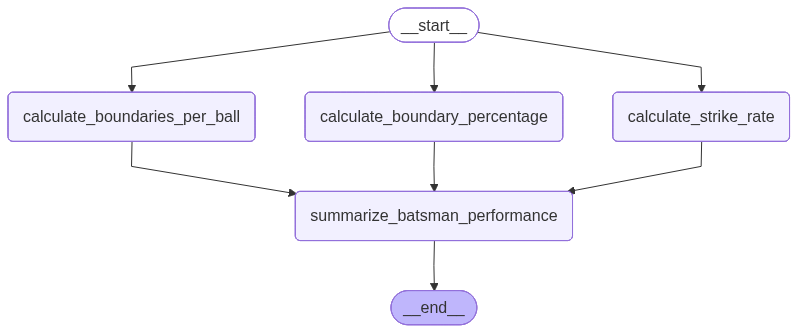

In [15]:
graph = StateGraph(BatsmanState)
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_boundaries_per_ball", calculate_boundaries_per_ball)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
graph.add_node("summarize_batsman_performance", summarize_batsman_performance)

#edges
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundaries_per_ball")
graph.add_edge(START, "calculate_boundary_percentage")
graph.add_edge("calculate_strike_rate", "summarize_batsman_performance")
graph.add_edge("calculate_boundaries_per_ball", "summarize_batsman_performance")
graph.add_edge("calculate_boundary_percentage", "summarize_batsman_performance")
graph.add_edge("summarize_batsman_performance", END)

workflow = graph.compile()
workflow

In [17]:
initial_state = {
    "name": "Virat Kohli",
    "runs": 100,
    "balls": 50,
    "no_of_fours": 6,
    "no_of_sixes": 4
}

result = workflow.invoke(initial_state)
result

{'name': 'Virat Kohli',
 'runs': 100,
 'balls': 50,
 'no_of_fours': 6,
 'no_of_sixes': 4,
 'strike_rate': 200.0,
 'boundaries_per_ball': 0.2,
 'boundary_percentage': 20.0,
 'summary': 'Virat Kohli scored 100 runs off 50 balls, with a strike rate of 200.00, 0.2000 boundaries per ball, and a boundary percentage of 20.00%.'}